#### 1 - Imports and paths

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import mne
import matplotlib.pyplot as plt

In [2]:
PROJECT_ROOT = Path(r"C:\Users\maria\Desktop\EEG-special-course")
PROCESSED_ROOT = PROJECT_ROOT / "data_processed"

manifest_file = PROCESSED_ROOT / "manifest_pre_ses1.csv"
manifest = pd.read_csv(manifest_file)

display(manifest.head())

,participant_id,age,eyes_closed_file,eyes_open_file
0,sub-001,60,C:\Users\maria\Desktop\EEG-special-course\data...,C:\Users\maria\Desktop\EEG-special-course\data...
1,sub-002,67,C:\Users\maria\Desktop\EEG-special-course\data...,C:\Users\maria\Desktop\EEG-special-course\data...
2,sub-003,44,C:\Users\maria\Desktop\EEG-special-course\data...,C:\Users\maria\Desktop\EEG-special-course\data...
3,sub-004,24,C:\Users\maria\Desktop\EEG-special-course\data...,C:\Users\maria\Desktop\EEG-special-course\data...
4,sub-005,48,C:\Users\maria\Desktop\EEG-special-course\data...,C:\Users\maria\Desktop\EEG-special-course\data...


#### 2 - Channel selection helpers

In [3]:
OCCIPITAL_CHANNELS = ["O1", "Oz", "O2"]

def get_channels(raw, channel_set="posterior"):
    ch_names = raw.ch_names

    if channel_set == "oz":
        if "Oz" not in ch_names:
            raise ValueError("Oz not found")
        return ["Oz"]

    elif channel_set == "occipital":
        picks = [ch for ch in OCCIPITAL_CHANNELS if ch in ch_names]
        if len(picks) == 0:
            raise ValueError("No occipital channels found")
        return picks

    elif channel_set == "posterior":
        picks = [
            ch for ch in ch_names
            if ch.upper().startswith(("P", "PO", "O"))
        ]
        if len(picks) == 0:
            raise ValueError("No posterior channels found")
        return picks

    else:
        raise ValueError("channel_set must be 'oz', 'occipital', or 'posterior'")

#### 3 - Load and preprocess one EDF

In [5]:
def load_and_preprocess_raw(edf_path):
    raw = mne.io.read_raw_edf(edf_path, preload=True, verbose="ERROR")
    raw.pick("eeg")

    raw.resample(250, npad="auto")
    raw.filter(1.0, 40.0, verbose="ERROR")
    raw.notch_filter(freqs=[50.0], verbose="ERROR")
    raw.set_eeg_reference("average", verbose="ERROR")

    return raw

#### 4 - Compute alpha power for 30-second epochs

In [6]:
def compute_epoch_alpha_power(
    edf_path,
    condition,
    participant_id,
    channel_set="posterior",
    epoch_length=30.0,
    alpha_band=(8.0, 12.0)
):
    raw = load_and_preprocess_raw(edf_path)

    picks = get_channels(raw, channel_set=channel_set)
    raw.pick(picks)

    epochs = mne.make_fixed_length_epochs(
        raw,
        duration=epoch_length,
        overlap=0.0,
        preload=True,
        verbose="ERROR"
    )

    if len(epochs) == 0:
        return pd.DataFrame()

    psd = epochs.compute_psd(
        method="welch",
        fmin=alpha_band[0],
        fmax=alpha_band[1],
        verbose="ERROR"
    )

    psds, freqs = psd.get_data(return_freqs=True)
    # shape: epochs x channels x freqs

    alpha_per_epoch_channel = np.trapz(psds, freqs, axis=2)
    # shape: epochs x channels

    if channel_set == "oz":
        alpha_per_epoch = alpha_per_epoch_channel[:, 0]
    else:
        # Sum across channels, matching the posterior-alpha baseline logic
        alpha_per_epoch = alpha_per_epoch_channel.sum(axis=1)

    # log-transform for consistency with feature table
    alpha_per_epoch = np.log10(alpha_per_epoch)

    out = pd.DataFrame({
        "participant_id": participant_id,
        "condition": condition,
        "channel_set": channel_set,
        "epoch_index": np.arange(len(alpha_per_epoch)),
        "alpha_power_8_12": alpha_per_epoch,
        "n_channels": len(picks)
    })

    return out

#### 5 - Run for all participants

In [7]:
def build_epoch_alpha_table(manifest, channel_set="posterior"):
    rows = []

    for i, row in manifest.iterrows():
        participant_id = row["participant_id"]

        print(f"{i+1}/{len(manifest)} {participant_id} ({channel_set})")

        try:
            ec_epochs = compute_epoch_alpha_power(
                row["eyes_closed_file"],
                condition="EyesClosed",
                participant_id=participant_id,
                channel_set=channel_set
            )

            eo_epochs = compute_epoch_alpha_power(
                row["eyes_open_file"],
                condition="EyesOpen",
                participant_id=participant_id,
                channel_set=channel_set
            )

            rows.append(ec_epochs)
            rows.append(eo_epochs)

        except Exception as e:
            print(f"Skipping {participant_id}: {e}")

    epoch_df = pd.concat(rows, ignore_index=True)

    return epoch_df

In [8]:
epoch_posterior = build_epoch_alpha_table(
    manifest,
    channel_set="posterior"
)

display(epoch_posterior.head())
print(epoch_posterior.shape)

1/608 sub-001 (posterior)


C:\Users\maria\AppData\Local\Temp\ipykernel_24324\3225306862.py:35: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  alpha_per_epoch_channel = np.trapz(psds, freqs, axis=2)
C:\Users\maria\AppData\Local\Temp\ipykernel_24324\3225306862.py:35: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  alpha_per_epoch_channel = np.trapz(psds, freqs, axis=2)


2/608 sub-002 (posterior)


C:\Users\maria\AppData\Local\Temp\ipykernel_24324\3225306862.py:35: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  alpha_per_epoch_channel = np.trapz(psds, freqs, axis=2)
C:\Users\maria\AppData\Local\Temp\ipykernel_24324\3225306862.py:35: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  alpha_per_epoch_channel = np.trapz(psds, freqs, axis=2)


3/608 sub-003 (posterior)


...

C:\Users\maria\AppData\Local\Temp\ipykernel_24324\3225306862.py:35: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  alpha_per_epoch_channel = np.trapz(psds, freqs, axis=2)
C:\Users\maria\AppData\Local\Temp\ipykernel_24324\3225306862.py:35: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  alpha_per_epoch_channel = np.trapz(psds, freqs, axis=2)


608/608 sub-608 (posterior)


C:\Users\maria\AppData\Local\Temp\ipykernel_24324\3225306862.py:35: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  alpha_per_epoch_channel = np.trapz(psds, freqs, axis=2)
C:\Users\maria\AppData\Local\Temp\ipykernel_24324\3225306862.py:35: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  alpha_per_epoch_channel = np.trapz(psds, freqs, axis=2)


,participant_id,condition,channel_set,epoch_index,alpha_power_8_12,n_channels
0,sub-001,EyesClosed,posterior,0,-9.016162,19
1,sub-001,EyesClosed,posterior,1,-9.092940,19
2,sub-001,EyesClosed,posterior,2,-9.026158,19
3,sub-001,EyesClosed,posterior,3,-8.988984,19
4,sub-001,EyesClosed,posterior,4,-9.032515,19


(7341, 6)


#### Cell 6 — Median-threshold classifier

In [9]:
def apply_median_epoch_classifier(epoch_df):
    df = epoch_df.copy()

    df["participant_median_alpha"] = (
        df.groupby("participant_id")["alpha_power_8_12"]
        .transform("median")
    )

    df["predicted_condition"] = np.where(
        df["alpha_power_8_12"] > df["participant_median_alpha"],
        "EyesClosed",
        "EyesOpen"
    )

    df["correct"] = df["predicted_condition"] == df["condition"]

    accuracy = df["correct"].mean()

    summary = {
        "channel_set": df["channel_set"].iloc[0],
        "accuracy": accuracy,
        "n_epochs": len(df),
        "n_participants": df["participant_id"].nunique(),
        "n_correct": df["correct"].sum(),
        "n_incorrect": (~df["correct"]).sum()
    }

    return df, summary

In [10]:
classified_posterior, summary_posterior = apply_median_epoch_classifier(epoch_posterior)

summary_posterior

{'channel_set': 'posterior',
 'accuracy': np.float64(0.8820324206511374),
 'n_epochs': 7341,
 'n_participants': 608,
 'n_correct': np.int64(6475),
 'n_incorrect': np.int64(866)}

#### Cell 7 — Repeat for Oz and occipital channels

In [11]:
epoch_oz = build_epoch_alpha_table(
    manifest,
    channel_set="oz"
)

classified_oz, summary_oz = apply_median_epoch_classifier(epoch_oz)

summary_oz

epoch_occipital = build_epoch_alpha_table(
    manifest,
    channel_set="occipital"
)

classified_occipital, summary_occipital = apply_median_epoch_classifier(epoch_occipital)

summary_occipital

1/608 sub-001 (oz)


C:\Users\maria\AppData\Local\Temp\ipykernel_24324\3225306862.py:35: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  alpha_per_epoch_channel = np.trapz(psds, freqs, axis=2)
C:\Users\maria\AppData\Local\Temp\ipykernel_24324\3225306862.py:35: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  alpha_per_epoch_channel = np.trapz(psds, freqs, axis=2)


2/608 sub-002 (oz)


C:\Users\maria\AppData\Local\Temp\ipykernel_24324\3225306862.py:35: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  alpha_per_epoch_channel = np.trapz(psds, freqs, axis=2)
C:\Users\maria\AppData\Local\Temp\ipykernel_24324\3225306862.py:35: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  alpha_per_epoch_channel = np.trapz(psds, freqs, axis=2)


3/608 sub-003 (oz)


...

607/608 sub-607 (occipital)


C:\Users\maria\AppData\Local\Temp\ipykernel_24324\3225306862.py:35: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  alpha_per_epoch_channel = np.trapz(psds, freqs, axis=2)
C:\Users\maria\AppData\Local\Temp\ipykernel_24324\3225306862.py:35: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  alpha_per_epoch_channel = np.trapz(psds, freqs, axis=2)


608/608 sub-608 (occipital)


C:\Users\maria\AppData\Local\Temp\ipykernel_24324\3225306862.py:35: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  alpha_per_epoch_channel = np.trapz(psds, freqs, axis=2)
C:\Users\maria\AppData\Local\Temp\ipykernel_24324\3225306862.py:35: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  alpha_per_epoch_channel = np.trapz(psds, freqs, axis=2)


{'channel_set': 'occipital',
 'accuracy': np.float64(0.8795804386323389),
 'n_epochs': 7341,
 'n_participants': 608,
 'n_correct': np.int64(6457),
 'n_incorrect': np.int64(884)}

In [12]:
epoch_alpha_df = pd.concat(
    [epoch_oz, epoch_occipital, epoch_posterior],
    ignore_index=True
)

classified_epoch_alpha_df = pd.concat(
    [classified_oz, classified_occipital, classified_posterior],
    ignore_index=True
)

epoch_alpha_df.to_csv(
    PROCESSED_ROOT / "epoch_alpha_30s_all_channel_sets.csv",
    index=False
)

classified_epoch_alpha_df.to_csv(
    PROCESSED_ROOT / "epoch_alpha_30s_all_channel_sets_classified.csv",
    index=False
)

print("Saved combined epoch tables.")
print(epoch_alpha_df.shape)
print(classified_epoch_alpha_df.shape)

Saved combined epoch tables.
(22023, 6)
(22023, 9)


In [13]:
epoch_results = pd.DataFrame([
    summary_oz,
    summary_occipital,
    summary_posterior
])

display(epoch_results)

,channel_set,accuracy,n_epochs,n_participants,n_correct,n_incorrect
0,oz,0.859692,7341,608,6311,1030
1,occipital,0.879580,7341,608,6457,884
2,posterior,0.882032,7341,608,6475,866


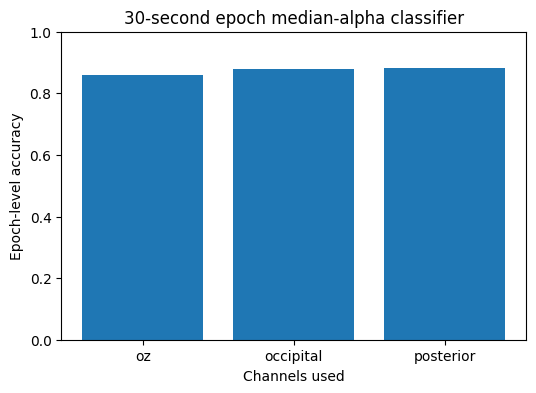

In [14]:
plt.figure(figsize=(6, 4))

plt.bar(
    epoch_results["channel_set"],
    epoch_results["accuracy"]
)

plt.ylim(0, 1)
plt.ylabel("Epoch-level accuracy")
plt.xlabel("Channels used")
plt.title("30-second epoch median-alpha classifier")

plt.show()

In [15]:
out_file = PROCESSED_ROOT / "epoch_alpha_median_classifier_results.csv"
epoch_results.to_csv(out_file, index=False)

print(f"Saved summary to: {out_file}")

Saved summary to: C:\Users\maria\Desktop\EEG-special-course\data_processed\epoch_alpha_median_classifier_results.csv


In [16]:
classified_posterior.to_csv(
    PROCESSED_ROOT / "epoch_alpha_posterior_classified.csv",
    index=False
)